# 📈 Starter Notebook: Predicting Stock Returns

Welcome to the Stock Return Prediction Project!

The goal of this competition is to predict the forward returns of an asset based strictly on historical price and volume data.

This notebook provides the bare minimum code to load the data, split it correctly, train a baseline model, and create a submission file. **However, the model in this notebook is intentionally terrible.** It is up to you to engineer the features that will actually find the signal in the noise.

## Resources

First, let's download the necessary data files from GitHub. **Please replace the placeholder URLs with the actual raw GitHub links to your `train.csv` and `test.csv` files.**

In [102]:
train_csv_url = 'https://raw.githubusercontent.com/Priyesha710/CSOT-Quant/main/week-2/project/data/train.csv'
!wget -O train.csv $train_csv_url
test_csv_url = 'https://raw.githubusercontent.com/Priyesha710/CSOT-Quant/main/week-2/project/data/test.csv'
!wget -O test.csv $test_csv_url

--2026-06-15 19:43:59--  https://raw.githubusercontent.com/Priyesha710/CSOT-Quant/main/week-2/project/data/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 445424 (435K) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>] 434.98K  --.-KB/s    in 0.03s   

2026-06-15 19:43:59 (14.0 MB/s) - ‘train.csv’ saved [445424/445424]

--2026-06-15 19:44:00--  https://raw.githubusercontent.com/Priyesha710/CSOT-Quant/main/week-2/project/data/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 100645

In [103]:
!pip install ta xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta
import xgboost as xgb

from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

plt.style.use('seaborn-v0_8-whitegrid')

print("Loading data...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
display(train_df.head())

Loading data...
Training data shape: (1989, 13)
Test data shape: (498, 12)


,id,Date,Open,High,Low,Close,Volume,feature_ret_1d,feature_ret_5d,feature_sma_20_ratio,feature_vol_ratio_20d,feature_high_low_spread,target
0,0,2014-01-30,145.258090,146.054110,144.795091,145.582993,118938100,0.010601,-0.019476,-0.016530,1.018317,0.008648,0.021090
1,1,2014-01-31,143.779734,145.631706,143.706633,144.730087,194677900,-0.005859,-0.003969,-0.021019,1.614905,0.013301,0.032776
2,2,2014-02-03,144.559525,144.884428,141.196732,141.472900,254837100,-0.022505,-0.021572,-0.040753,1.972072,0.026066,0.057817
3,3,2014-02-04,142.106482,142.829401,141.424179,142.463882,165012400,0.007005,-0.020551,-0.032176,1.249410,0.009864,0.043503
4,4,2014-02-05,141.968372,142.601941,141.099250,142.285156,164230500,-0.001255,-0.012292,-0.031169,1.207785,0.010561,0.050979


In [104]:
print(train_df.columns)

Index(['id', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume',
       'feature_ret_1d', 'feature_ret_5d', 'feature_sma_20_ratio',
       'feature_vol_ratio_20d', 'feature_high_low_spread', 'target'],
      dtype='object')


## 1. Feature Engineering (YOUR TURN)

Machine learning models cannot predict the future just by looking at raw prices. If you feed the model an absolute price like `$450`, it doesn't know if that is relatively high or low. If you use raw prices, your model will overfit and fail on the test set.

You must transform the raw `Open`, `High`, `Low`, `Close`, and `Volume` columns into **relative features** (e.g., percentage changes, moving average ratios, volatility windows).

**Rules for this section:**
1. You can only use past data to create features for today (no looking ahead).
2. You MUST drop the raw price columns before passing the data to your model.

In [105]:
import numpy as np
import pandas as pd
import ta
import warnings

# Suppress the Pandas fillna future warning
warnings.filterwarnings('ignore', category=FutureWarning)

def engineer_features(df):
    """
    Apply all feature engineering inside this function.
    Iteration 5: Macro Variables, Rolling Z-Scores, and Symmetrical Clipping.
    """
    data = df.copy()

    # 1. CALENDAR / TEMPORAL FEATURES
    if 'Date' in data.columns:
        data['Date'] = pd.to_datetime(data['Date'])
        data['month'] = data['Date'].dt.month

    # 2. MACRO VOLATILITY & Z-SCORES
    if 'feature_ret_1d' in data.columns:
        data['vol_5'] = data['feature_ret_1d'].rolling(5).std()
        data['vol_20'] = data['feature_ret_1d'].rolling(20).std()
        data['vol_60'] = data['feature_ret_1d'].rolling(60).std()
        data['vol_regime'] = data['vol_20'] / data['vol_60']

    atr_14 = ta.volatility.AverageTrueRange(
        high=data['High'], low=data['Low'], close=data['Close'], window=14
    ).average_true_range()

    atr_5 = ta.volatility.AverageTrueRange(
        high=data['High'], low=data['Low'], close=data['Close'], window=5
    ).average_true_range()

    data['feature_atr_ratio'] = atr_5 / atr_14

    atr_mean = atr_14.rolling(60).mean()
    atr_std = atr_14.rolling(60).std()
    data['feature_atr_zscore'] = (atr_14 - atr_mean) / atr_std

    # 3. MACRO TREND & MOMENTUM
    data['sma_20'] = data['Close'].rolling(20).mean()
    data['sma_60'] = data['Close'].rolling(60).mean()
    data['dist_from_sma_20'] = (data['Close'] - data['sma_20']) / data['sma_20']
    data['dist_from_sma_60'] = (data['Close'] - data['sma_60']) / data['sma_60']

    data['feature_rsi'] = ta.momentum.RSIIndicator(data['Close'], window=14).rsi()
    data['feature_rsi_30'] = ta.momentum.RSIIndicator(data['Close'], window=30).rsi()

    macd_indicator = ta.trend.MACD(data['Close'])
    data['feature_macd_diff_pct'] = macd_indicator.macd_diff() / data['Close']

    # 4. LAGGED FEATURES
    cols_to_lag = ['feature_rsi', 'feature_macd_diff_pct']
    for col in cols_to_lag:
        if col in data.columns:
            data[f'{col}_lag1'] = data[col].shift(1)
            data[f'{col}_lag2'] = data[col].shift(2)

    # 5. CLEANUP
    columns_to_drop = [
        'id', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume',
        'feature_ret_1d', 'sma_20', 'sma_60', 'feature_vol_ratio_20d',
        'dist_from_sma_20', 'volume_zscore', 'feature_sma_20_ratio'
    ]
    data = data.drop(columns=columns_to_drop, errors='ignore')

    return data

# ==============================================================================
# 🚨 DATA PROCESSING & SAFETY SPLITS (CORRECTED)
# ==============================================================================
print("Processing features...")

# 1. Process Train Data
X_train_full = engineer_features(train_df)
feature_cols = [col for col in X_train_full.columns if col not in ['id', 'target', 'Date']]

# Drop rows where rolling features are NaN
X_train_full = X_train_full.dropna(subset=feature_cols + ['target'])

# 2. Isolate, Clip, and SCALE the Target
CLIP_LIMIT = 0.15
# Multiply target by 100 to give XGBoost larger gradients to work with
y_train_full = X_train_full['target'].clip(lower=-CLIP_LIMIT, upper=CLIP_LIMIT) * 100
X_train_features = X_train_full[feature_cols]

# 3. Process Test Data SAFELY (Prevent NaN Wipeout)
train_tail = train_df.tail(60)
test_df_combined = pd.concat([train_tail, test_df], ignore_index=True)
X_test_combined = engineer_features(test_df_combined)

# Slice off the 60 borrowed rows
X_test = X_test_combined.iloc[60:].reset_index(drop=True)

# 4. Fill remaining NaNs safely
X_test_features = X_test[feature_cols].ffill().fillna(0)

print(f"Training features shape: {X_train_features.shape}")
print(f"Test features shape: {X_test_features.shape}")

Processing features...
Training features shape: (1930, 17)
Test features shape: (498, 17)


In [106]:
X_train_full[feature_cols + ['target']].corr()['target'].sort_values()

,target
dist_from_sma_60,-0.157063
feature_rsi_30,-0.137293
feature_rsi,-0.105394
feature_rsi_lag2,-0.095934
feature_rsi_lag1,-0.095677
feature_atr_ratio,-0.060210
feature_atr_zscore,-0.019409
feature_ret_5d,-0.010146
month,-0.002927
vol_regime,0.002395


## 2. Validation Split

To know if our model actually works, we need to test it on data it hasn't seen during training. Because this is financial time-series data, **we cannot randomly shuffle the rows.** We must split it chronologically.

## 3. Building the Model

When you calculate rolling averages or lagged features, the first few rows of your dataset will contain `NaN` (Not a Number) values. Models crash if they see a `NaN`.

We use a `Pipeline` to automatically fill those missing values (`SimpleImputer`) before passing the data to our `LinearRegression` model.

In [107]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import numpy as np

# 1. Define the Time Series Splitter
tscv = TimeSeriesSplit(n_splits=5)
fold_scores = []

X_train_features_reset = X_train_features.reset_index(drop=True)
y_train_full_reset = y_train_full.reset_index(drop=True)

print("Starting Purged Rolling Window Validation...\n")

# 🚨 THE EMBARGO FIX: Number of days to drop between Train and Validation
# Assuming target is a 5-day forward return, we drop 5 days.
EMBARGO_DAYS = 5

# 2. Loop through each rolling window
for fold, (train_index, val_index) in enumerate(tscv.split(X_train_features_reset)):
    print(f"--- Fold {fold + 1} ---")

    # Apply embargo to prevent overlap leakage
    if len(train_index) > EMBARGO_DAYS:
        train_index = train_index[:-EMBARGO_DAYS]

    X_train_fold = X_train_features_reset.iloc[train_index]
    y_train_fold = y_train_full_reset.iloc[train_index]
    X_val_fold = X_train_features_reset.iloc[val_index]
    y_val_fold = y_train_full_reset.iloc[val_index]

    print(f"Training on {len(X_train_fold)} rows, Validating on {len(X_val_fold)} rows.")

    # 3. Initialize model (Updated to Pseudo-Huber for outlier robustness)
    model = XGBRegressor(
        n_estimators=2000,
        max_depth=3,
        learning_rate=0.01,
        subsample=0.5,
        colsample_bytree=0.4,
        min_child_weight=10,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=19,
        early_stopping_rounds=100,
        objective='reg:pseudohubererror',
        eval_metric='mae'
    )

    # 4. Train with early stopping
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        verbose=False
    )

    # 5. Predict and Evaluate
    val_predictions = model.predict(X_val_fold)
    fold_r2 = r2_score(y_val_fold, val_predictions)

    if hasattr(model, 'best_iteration'):
        print(f"Stopped at Tree: {model.best_iteration}")
    else:
        print("Early stopping did not activate.")

    print(f"Fold {fold + 1} R²: {fold_r2:.6f}\n")
    fold_scores.append(fold_r2)

# 6. Final Results
print("========================================")
print(f"✅ Average Purged R-Squared (R²): {np.mean(fold_scores):.6f}")
print("========================================")

if np.mean(fold_scores) <= 0:
    print("⚠️ Your average R² is zero or negative. Your model is currently worse than guessing the average.")

Starting Purged Rolling Window Validation...

--- Fold 1 ---
Training on 320 rows, Validating on 321 rows.
Stopped at Tree: 79
Fold 1 R²: 0.003396

--- Fold 2 ---
Training on 641 rows, Validating on 321 rows.
Stopped at Tree: 0
Fold 2 R²: -0.044044

--- Fold 3 ---
Training on 962 rows, Validating on 321 rows.
Stopped at Tree: 104
Fold 3 R²: -0.030648

--- Fold 4 ---
Training on 1283 rows, Validating on 321 rows.
Stopped at Tree: 76
Fold 4 R²: 0.006080

--- Fold 5 ---
Training on 1604 rows, Validating on 321 rows.
Stopped at Tree: 140
Fold 5 R²: 0.045914

✅ Average Purged R-Squared (R²): -0.003860
⚠️ Your average R² is zero or negative. Your model is currently worse than guessing the average.


### Feature Importance Analysis & Pruning Strategy

After running the initial XGBoost model, I extracted the feature importances (Gain) to determine which signals the model was actually using to split the decision trees. The results are below:

| Feature | Importance Score |
| :--- | :--- |
| `vol_5` | 0.136863 |
| `feature_macd_diff_pct` | 0.095825 |
| `feature_atr` | 0.082014 |
| `feature_macd_diff_pct_lag2` | 0.080445 |
| `vol_20` | 0.062092 |
| `feature_macd_diff_pct_lag1` | 0.061024 |
| `month` | 0.048949 |
| `volume_spike` | 0.046125 |
| `feature_ret_5d` | 0.042994 |
| `feature_vol_ratio_20d` | 0.040167 |
| `vol_ratio` | 0.039074 |
| `feature_rsi_lag2` | 0.036894 |
| `feature_rsi` | 0.035723 |
| `feature_sma_20_ratio` | 0.034578 |
| `feature_rsi_lag1` | 0.031928 |
| `feature_ret_1d_lag2` | 0.027788 |
| `feature_ret_1d` | 0.027626 |
| `feature_high_low_spread` | 0.027350 |
| `feature_ret_1d_lag1` | 0.022757 |
| `day_of_week` | 0.019783 |

**Observations & Iteration 2 Strategy:**
1. **Volatility is Key:** The model heavily relies on volatility metrics (`vol_5`, `feature_atr`, `vol_20`) to find alpha.
2. **Momentum Trajectory:** Converting the MACD difference into a stationary percentage and adding lags (`lag1`, `lag2`) was highly successful, capturing the top spots just below short-term volatility.
3. **Dropping the Noise:** The bottom features—specifically the raw 1-day returns (`feature_ret_1d` and its lags) and `day_of_week`—contributed very little predictive gain. In Iteration 2 of the feature engineering pipeline, these features were pruned to reduce dimensionality and prevent the model from overfitting on noisy, low-value signals.

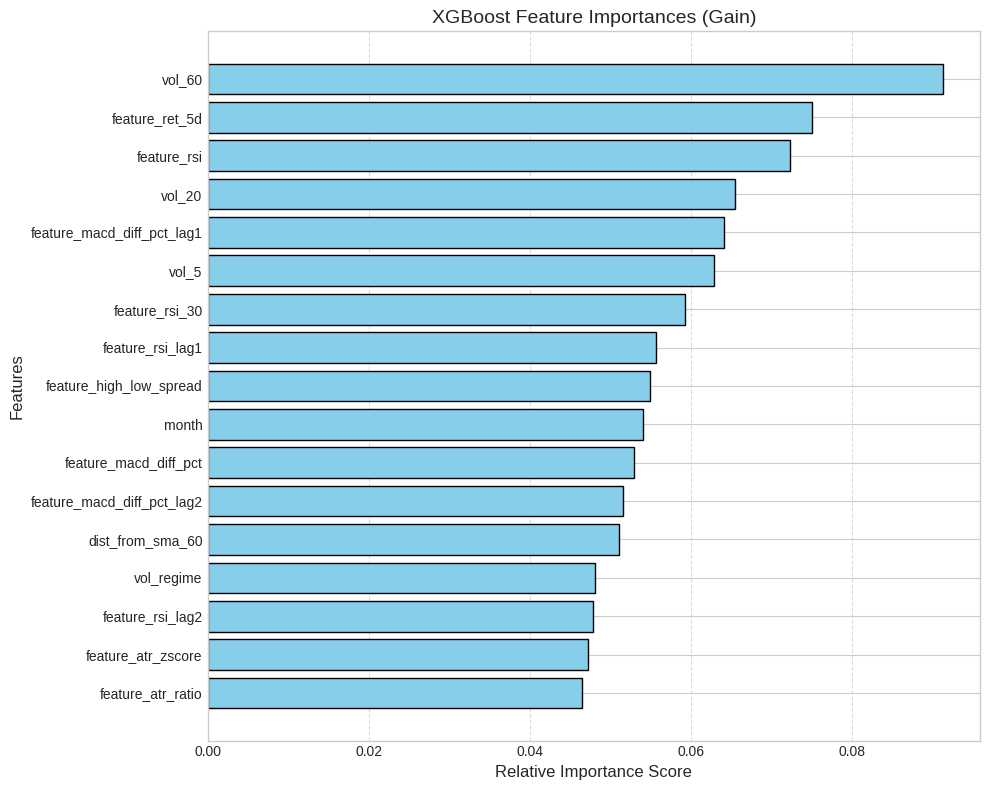


Most Important Features:
                   Feature  Importance
                    vol_60    0.091302
            feature_ret_5d    0.074956
               feature_rsi    0.072318
                    vol_20    0.065412
feature_macd_diff_pct_lag1    0.064137
                     vol_5    0.062840
            feature_rsi_30    0.059269
          feature_rsi_lag1    0.055713
   feature_high_low_spread    0.054856
                     month    0.054012
     feature_macd_diff_pct    0.052867
feature_macd_diff_pct_lag2    0.051617
          dist_from_sma_60    0.051019
                vol_regime    0.048105
          feature_rsi_lag2    0.047796
        feature_atr_zscore    0.047278
         feature_atr_ratio    0.046502


In [108]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Grab the importances directly from the model
importances = model.feature_importances_
feature_names = model.feature_names_in_

# 2. Create a clean DataFrame matching the scores to the feature names
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. Sort the features from least to most important
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# 4. Plot the results horizontally
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue', edgecolor='black')
plt.title("XGBoost Feature Importances (Gain)", fontsize=14)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Print the top raw numbers
print("\nMost Important Features:")
print(importance_df.sort_values(by='Importance', ascending=False).to_string(index=False))

## 4. Generate Final Submission

Once you are happy with your validation score, it is time to generate predictions for `test.csv`.
We will retrain the model on the *entire* training dataset so it learns from the most recent data, and then predict the future.

In [109]:
# ==========================================
# 🏆 THE FINAL SUBMISSION PIPELINE 🏆
# ==========================================
print("Training Final Model on ALL data...")

# 1. Initialize Final Model
# Note: Objective is matched to the Pseudo-Huber tested in validation
final_model = XGBRegressor(
    n_estimators=160, # Adjust this based on your average best_iteration from CV
    max_depth=3,
    learning_rate=0.01,
    subsample=0.6,
    colsample_bytree=0.6,
    min_child_weight=20,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42,
    objective='reg:pseudohubererror'
)

# 2. Train on 100% of the training data
final_model.fit(X_train_features, y_train_full)

# 3. Predict on the hidden Test Set
test_predictions = final_model.predict(X_test_features)

# 4. Format Submission exactly as required by the competition
submission = pd.DataFrame({
    'id': test_df['id'],
    'target': test_predictions
})

# 5. Save to CSV
submission_filename = 'final_submission.csv'
submission.to_csv(submission_filename, index=False)

print(f"\n🎉 Success! Final predictions saved to '{submission_filename}'.")

Training Final Model on ALL data...

🎉 Success! Final predictions saved to 'final_submission.csv'.
